In [1]:
#from B_1_NY2 import (
#    NeuralNetworkModel,
#    Losses_MSE,
#    Losses_MSE_Batched,
#    RiemannianMetric,
#    RiemannianMetricBatched,
#    Brownian_sampler,
#    Brownian_sampler_batched,
#)
#from C_NN import Net_2_Layer, Train_Net
#import numpy as np
#import torch
#import matplotlib.pyplot as plt
#
#torch.set_default_dtype(torch.float64)
#
## ---- bigger dataset so batched gradients are statistically meaningful ----
#N_data = 50
#x_data = np.linspace(1, 5, N_data, dtype=np.float64)
#y_data = np.sin(2 * x_data) + np.cos(4 * x_data)
#
#x_mean, x_std = x_data.mean(), x_data.std()
#y_mean, y_std = y_data.mean(), y_data.std()
#
#x_data_n = (x_data - x_mean) / x_std
#y_data_n = (y_data - y_mean) / y_std
#
#x_tensor = torch.from_numpy(x_data_n).view(-1, 1)
#y_tensor = torch.from_numpy(y_data_n).view(-1, 1)
#
#x_grid_np     = np.linspace(0, 6, 1000, dtype=np.float64)
#x_grid_n      = (x_grid_np - x_mean) / x_std
#x_grid_tensor = torch.from_numpy(x_grid_n).view(-1, 1)
#
## ---- net config (identical to your existing cell 6) ----
#activation_func = "silu"   # requires the SiLU fix in C_NN.py and the silu branch in NeuralNetworkModel
#N_hidden  = 16
#N_hidden2 = 16
#N_sample  = 100
#
## Single seed, as requested
#torch.manual_seed(0)
#np.random.seed(0)
#
#model    = Net_2_Layer(N_hidden, N_hidden2, activation_type=activation_func).double()
#model_VI = NeuralNetworkModel([1, N_hidden, N_hidden2, 1],
#                              activation_type=activation_func)
#
#dim = model_VI.theta_dim
#print(f"theta_dim = {dim}, N_data = {N_data}")
#
#theta = Train_Net(model, 20000, x_tensor, y_tensor, lr=0.001)
#
#with torch.no_grad():
#    predicted = model(x_grid_tensor).numpy() * y_std + y_mean

In [2]:
from B_1_NY2 import (
    NeuralNetworkModel,
    Losses_MSE,
    Losses_MSE_Batched,
    RiemannianMetric,
    RiemannianMetricBatched,
    Brownian_sampler,
    Brownian_sampler_batched,
)
from C_NN import Net_2_Layer, Train_Net
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# ---- dataset: dense on the sides, GAP in the middle.
# This is where batched vs rank-1 metric can show qualitatively different
# behavior: in the gap the posterior MUST spread, and the per-batch
# disagreement is meaningful (the data has nothing to say about that x range,
# so different subsets imply different interpolants).
N_left  = 25     # points in [1.0, 2.3]
N_right = 25     # points in [3.7, 5.0]
N_data  = N_left + N_right

x_left  = np.linspace(1.0, 2.3, N_left,  dtype=np.float64)
x_right = np.linspace(3.7, 5.0, N_right, dtype=np.float64)
x_data  = np.concatenate([x_left, x_right])
y_data  = np.sin(2 * x_data) + np.cos(4 * x_data)

# Stats use ONLY the data, not the gap region (matches training setup).
x_mean, x_std = x_data.mean(), x_data.std()
y_mean, y_std = y_data.mean(), y_data.std()

x_data_n = (x_data - x_mean) / x_std
y_data_n = (y_data - y_mean) / y_std

x_tensor = torch.from_numpy(x_data_n).view(-1, 1)
y_tensor = torch.from_numpy(y_data_n).view(-1, 1)

# Grid spans the full range INCLUDING the gap, so we can see what the
# posterior predictive does over [2.3, 3.7].
x_grid_np     = np.linspace(0, 6, 1000, dtype=np.float64)
x_grid_n      = (x_grid_np - x_mean) / x_std
x_grid_tensor = torch.from_numpy(x_grid_n).view(-1, 1)

# Markers for plotting the gap region (lightly shaded).
gap_left, gap_right = 2.3, 3.7

# ---- net config (identical to your existing cell 6) ----
activation_func = "silu"   # requires the SiLU fix in C_NN.py and the silu branch in NeuralNetworkModel
N_hidden  = 16
N_hidden2 = 16
N_sample  = 100

# Single seed, as requested
torch.manual_seed(0)
np.random.seed(0)

model    = Net_2_Layer(N_hidden, N_hidden2, activation_type=activation_func).double()
model_VI = NeuralNetworkModel([1, N_hidden, N_hidden2, 1],
                              activation_type=activation_func)

dim = model_VI.theta_dim
print(f"theta_dim = {dim}, N_data = {N_data}")

theta = Train_Net(model, 20000, x_tensor, y_tensor, lr=0.001)

with torch.no_grad():
    predicted = model(x_grid_tensor).numpy() * y_std + y_mean

theta_dim = 321, N_data = 50
step [20000/20000], Loss: 0.0000


  S=1  walk=50  step=0.0001
  S=1  walk=100  step=0.0001
  S=8  walk=50  step=0.0001
  S=8  walk=100  step=0.0001


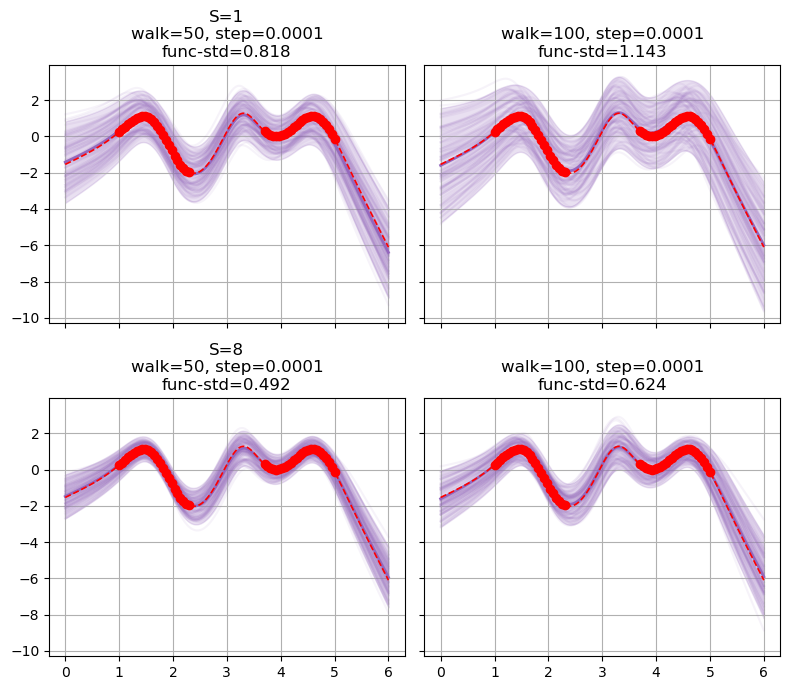

In [4]:
configs = [
    # Step sizes are bumped up vs the SSE notebook: MSE = SSE / N, so the
    # rank-S correction in M = I + (1/S) sum g_b g_b^T is ~N^2 times smaller.
    # For N=50 that's a factor 2500 in M's anisotropy.
    (50,  1e-4),
    (100,  1e-4),
    #(500,  5e-2),
    #(500,  1e-4),
    #(2000, 1e-2),
    #(2000, 1e-4),
]

S_values = [1, 8]# 4, 8, 16]   # S=1 reproduces the old behavior; rest are new

n_rows = len(S_values)
n_cols = len(configs)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3.5 * n_rows),
                         sharex=True, sharey=True)
if n_rows == 1:
    axes = axes[None, :]

# Pre-build one loss + metric per S (batch partition is fixed by batch_seed).
loss_and_metric_per_S = {}
for S in S_values:
    loss_b   = Losses_MSE_Batched(model_VI, x_data_n, y_data_n,
                                  S=S, batch_seed=0)
    metric_b = RiemannianMetricBatched(loss_b)
    loss_and_metric_per_S[S] = (loss_b, metric_b)

for row, S in enumerate(S_values):
    loss_b, metric_b = loss_and_metric_per_S[S]

    for col, (wl, ss) in enumerate(configs):
        print(f"  S={S}  walk={wl}  step={ss:g}")
        ax = axes[row, col]

        sampler = Brownian_sampler_batched(metric_b, walk_len=wl, step_size=ss,
                                           n_samples=N_sample)

        with torch.no_grad():
            theta_samples = sampler.sample_q_endpoints(theta.detach(),
                                                       detach_from_mu=True)
            y_pred = model_VI.forward_theta_batch(theta_samples,
                                                  x_grid_tensor).numpy()

        y_pred = y_pred * y_std + y_mean
        m_c = y_pred.mean(axis=0)
        s_c = y_pred.std(axis=0)

        for i in range(N_sample):
            ax.plot(x_grid_np, y_pred[i], color="tab:purple", alpha=0.08)
        ax.fill_between(x_grid_np, m_c - 2 * s_c, m_c + 2 * s_c,
                        color="tab:purple", alpha=0.20)
        ax.plot(x_grid_np, m_c, color="tab:purple", lw=2)
        ax.plot(x_grid_np, predicted, color="red", lw=1.2, ls="--")
        ax.scatter(x_data, y_data, color="red", zorder=5)

        title = f"walk={wl}, step={ss:g}\nfunc-std={s_c.mean():.3f}"
        if col == 0:
            title = f"S={S}\n" + title
        ax.set_title(title)
        ax.grid(True)

        del sampler, theta_samples, y_pred

plt.tight_layout()
plt.show()
